In [1]:
import pandas as pd
df = pd.read_parquet('../data/raw/valid-matches.parquet')

print(len(df), df['match_id'].min())

150031 8886947138


Loaded 150031 matches
num_slots = 156
radiant heroes:  5
dire heroes 5
Nonzero entries: 10
X.shape:  (150031, 156)
y.shape:  (150031,)
Test accuracy: 0.562
Radiant win rate (train): 0.533
Always-guess-radiant accuracy on test: 0.536
0.2-0.3: 13 matches, mean prediction=0.290, actual win rate=0.385
0.3-0.4: 886 matches, mean prediction=0.374, actual win rate=0.351
0.4-0.5: 8804 matches, mean prediction=0.462, actual win rate=0.470
0.5-0.6: 15250 matches, mean prediction=0.548, actual win rate=0.553
0.6-0.7: 4837 matches, mean prediction=0.632, actual win rate=0.624
0.7-0.8: 216 matches, mean prediction=0.719, actual win rate=0.736
0.8-0.9: 1 matches, mean prediction=0.822, actual win rate=0.000


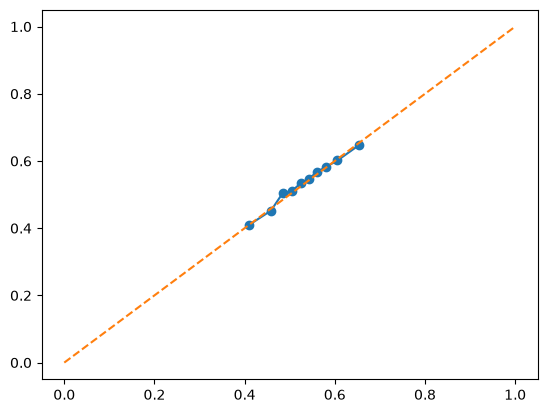

In [10]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# ---- Step 1: Load the data ----
# Read the parquet built in Phase 1 into a DataFrame.
# Path is relative to where we RUN this from (repo root, like before).
df = pd.read_parquet("../data/raw/valid-matches.parquet")
print(f"Loaded {len(df)} matches")   # confirm your real row count here

# -- sort, smaller matfch IDs are older.
df = df.sort_values('match_id').reset_index(drop=True)

# ---- Step 2: Find how many hero slots you need ----
# Ignoring the ID-gap, so num_slots = max hero ID + 1
# (the +1 so the highest ID is a valid array index).
# Hint: you need the max across BOTH radiant_team and dire_team columns.
# Each cell is a list, so a plain .max() won't work directly — think about
# how to get the largest single hero ID seen anywhere in either column.
all_matches = df.to_dict('records')
max_hero_id = max(
    hero_id 
    for match in all_matches
    for team_name in ("radiant_team", "dire_team")
    for hero_id in match[team_name]
)
num_slots = max_hero_id + 1
print(f"num_slots = {num_slots}")


# ---- Step 3: Encoder for ONE match ----
def encode_match(match, num_slots):
    row = np.zeros(num_slots)
    
    # TODO: put +1 at each radiant hero's index
    for hero_id in match["radiant_team"]:
        row[hero_id] = 1
    
    # TODO: put -1 at each dire hero's index
    for hero_id in match["dire_team"]:
        row[hero_id] = -1
    
    return row


# ---- Step 4: Test the encoder on a single match BEFORE scaling ----
# Grab one row (e.g. df.iloc[0]), encode it, and sanity-check:
#   - exactly five +1 values
#   - exactly five -1 values
#   - everything else 0
# Hint: np.sum(row == 1) and np.sum(row == -1) are quick checks.
test_row = encode_match(df.iloc[0], num_slots)
# TODO: print the two counts and confirm they're both 5
print("radiant heroes: ", np.sum(test_row == 1))
print("dire heroes", np.sum(test_row == -1))
print("Nonzero entries:", np.count_nonzero(test_row))


# ---- Step 5: Build the full feature matrix X ----
# Apply encode_match to every match, stack into one 2D array.
# Shape should end up (num_matches, num_slots).
# X = ...   # TODO (come back to this after Step 4 works)
X = np.array([encode_match(m,num_slots) for m in all_matches])

# ---- Step 6: Build the label vector y ----
# radiant_win is True/False; models want 1/0.
y = df['radiant_win'].astype(int).values

print("X.shape: ", X.shape)
print("y.shape: ", y.shape)


# ---- Step 7: split x and y
# rebuild all matches, X, y from this
# split (first 80% (older) = train), (last 20% (newer) = test) 
split_idx = int(len(df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# ---- Step 8: Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"Test accuracy: {accuracy:.3f}")

print(f"Radiant win rate (train): {y_train.mean():.3f}")
print(f"Always-guess-radiant accuracy on test: {y_test.mean():.3f}")

# ---- Step 9: predict freq
probs = model.predict_proba(X_test)[:, 1]   # P(radiant win) for each test match

bin_edges = np.linspace(0, 1, 11)

for i in range(10):
    lower = bin_edges[i]
    upper = bin_edges[i + 1]

    if i == 9:
        mask = (probs >= lower) & (probs <= upper)
    else:
        mask = (probs >= lower) & (probs < upper)

    count = np.sum(mask)

    if count > 0:
        mean_prediction = probs[mask].mean()
        actual_win_rate = y_test[mask].mean()

        print(
            f"{lower:.1f}-{upper:.1f}: "
            f"{count} matches, "
            f"mean prediction={mean_prediction:.3f}, "
            f"actual win rate={actual_win_rate:.3f}"
        )

true_freq, pred_freq = calibration_curve(y_test, probs, n_bins=10, strategy = 'quantile')

plt.plot(pred_freq, true_freq, marker = "o", label = "Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--", label = "Perfect Calibration")